# Phase 5 — Model Evaluation & Comparison
Confusion Matrix · Classification Report · Model Comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve)
from pathlib import Path
import json, time, warnings
warnings.filterwarnings('ignore')

DATASET_ROOT = Path('classification_dataset')
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32

# Load class indices
with open('class_indices.json') as f:
    class_indices = json.load(f)
CLASS_NAMES = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
print('Classes:', CLASS_NAMES)

Classes: ['bird', 'drone']


In [3]:
# Load test generator
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    DATASET_ROOT / 'TEST',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Load both models
print('Loading models...')
cnn_model = tf.keras.models.load_model('custom_cnn_best.keras')
tl_model  = tf.keras.models.load_model('tl_finetuned_best.keras')
print('Models loaded!')

Found 215 images belonging to 2 classes.


Loading models...
Models loaded!


## 5.1 — Predictions on Test Set

In [4]:
def evaluate_model(model, gen, model_name):
    gen.reset()
    t0 = time.time()
    probs = model.predict(gen, verbose=1).flatten()
    inference_time = time.time() - t0
    preds  = (probs > 0.5).astype(int)
    labels = gen.classes

    cm     = confusion_matrix(labels, preds)
    report = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)

    print(f'\n{'='*50}')
    print(f' {model_name}')
    print(f'{'='*50}')
    print(classification_report(labels, preds, target_names=CLASS_NAMES))
    print(f'Inference time on {len(labels)} images: {inference_time:.2f}s')
    print(f'Per-image: {1000*inference_time/len(labels):.1f}ms')

    return {'cm': cm, 'probs': probs, 'preds': preds,
            'labels': labels, 'report': report,
            'inference_time': inference_time}

cnn_results = evaluate_model(cnn_model, test_gen, 'Custom CNN')
test_gen.reset()
tl_results  = evaluate_model(tl_model,  test_gen, 'EfficientNetB0 (Transfer Learning)')

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 685ms/step

 Custom CNN
              precision    recall  f1-score   support

        bird       0.83      0.89      0.86       121
       drone       0.85      0.77      0.80        94

    accuracy                           0.84       215
   macro avg       0.84      0.83      0.83       215
weighted avg       0.84      0.84      0.84       215

Inference time on 215 images: 5.54s
Per-image: 25.8ms
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 872ms/step

 EfficientNetB0 (Transfer Learning)
              precision    recall  f1-score   support

        bird       0.00      0.00      0.00       121
       drone       0.44      1.00      0.61        94

    accuracy                           0.44       215
   macro avg       0.22      0.50      0.30       215
weighted avg       0.19      0.44      0.27       215

Inference time on 215 images: 8.76s
Per-image: 40.8ms


## 5.2 — Confusion Matrices

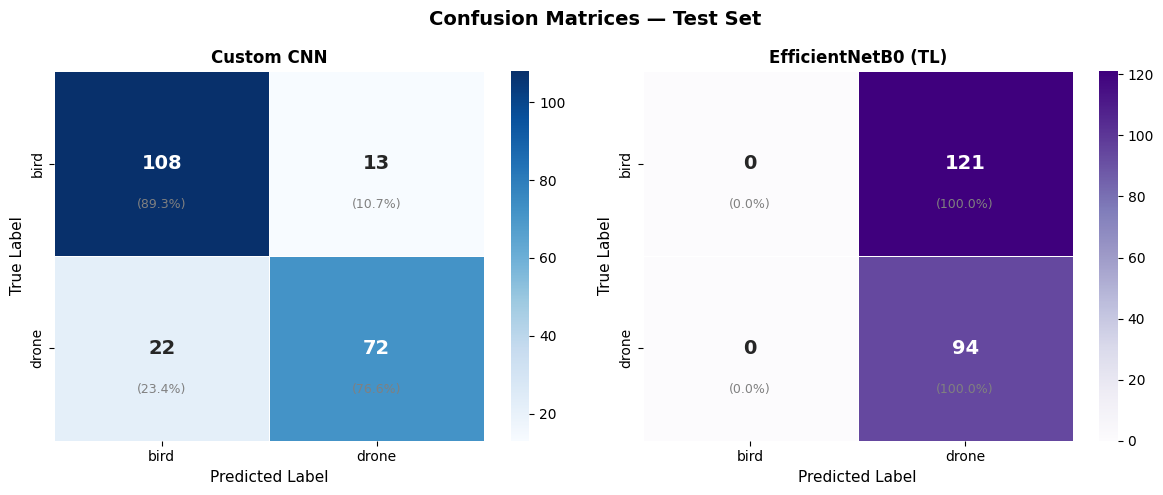

In [5]:
def plot_cm(cm, title, ax, cmap='Blues'):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    # Add percentage annotations
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j+0.5, i+0.72, f'({cm_norm[i,j]*100:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(cnn_results['cm'], 'Custom CNN',              axes[0], 'Blues')
plot_cm(tl_results['cm'],  'EfficientNetB0 (TL)',     axes[1], 'Purples')
plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 — ROC Curves

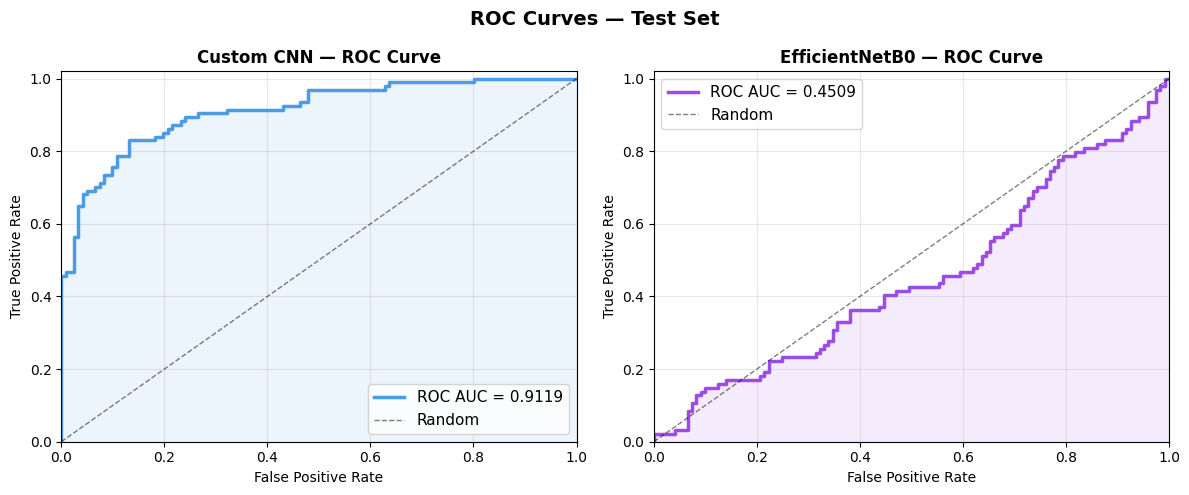

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, results, name, color in [
    (axes[0], cnn_results, 'Custom CNN',       '#4C9BE8'),
    (axes[1], tl_results,  'EfficientNetB0',   '#9B4CE8')
]:
    fpr, tpr, _ = roc_curve(results['labels'], results['probs'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'ROC AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'{name} — ROC Curve', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle('ROC Curves — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 — Model Comparison Summary

In [7]:
import pandas as pd

def extract_metrics(results, model_name):
    r = results['report']
    return {
        'Model':     model_name,
        'Accuracy':  f"{r['accuracy']*100:.2f}%",
        'Precision': f"{r['weighted avg']['precision']*100:.2f}%",
        'Recall':    f"{r['weighted avg']['recall']*100:.2f}%",
        'F1-Score':  f"{r['weighted avg']['f1-score']*100:.2f}%",
        'Inference': f"{1000*results['inference_time']/len(results['labels']):.1f}ms/img"
    }

comparison_df = pd.DataFrame([
    extract_metrics(cnn_results, 'Custom CNN'),
    extract_metrics(tl_results,  'EfficientNetB0 (TL)')
])
comparison_df = comparison_df.set_index('Model')
print('\n' + '='*60)
print(' MODEL COMPARISON REPORT')
print('='*60)
print(comparison_df.to_string())
comparison_df.to_csv('model_comparison.csv')
print('\nSaved: model_comparison.csv')


 MODEL COMPARISON REPORT
                    Accuracy Precision  Recall F1-Score   Inference
Model                                                              
Custom CNN            83.72%    83.79%  83.72%   83.60%  25.8ms/img
EfficientNetB0 (TL)   43.72%    19.12%  43.72%   26.60%  40.8ms/img

Saved: model_comparison.csv


## 5.5 — Save Best Model for Streamlit

In [9]:
import shutil

# Determine best model by accuracy
cnn_acc = cnn_results['report']['accuracy']
tl_acc  = tl_results['report']['accuracy']

if tl_acc >= cnn_acc:
    best_src  = 'tl_finetuned_best.keras'
    best_name = 'EfficientNetB0 (Transfer Learning)'
else:
    best_src  = 'custom_cnn_best.keras'
    best_name = 'Custom CNN'

shutil.copy(best_src, 'best_model.keras')
print(f'Best model: {best_name} (accuracy: {max(cnn_acc, tl_acc)*100:.2f}%)')
print(f'Saved as: best_model.keras ← used by Streamlit app')

Best model: Custom CNN (accuracy: 83.72%)
Saved as: best_model.keras ← used by Streamlit app


## 5.6 — Visualize Predictions on Test Samples

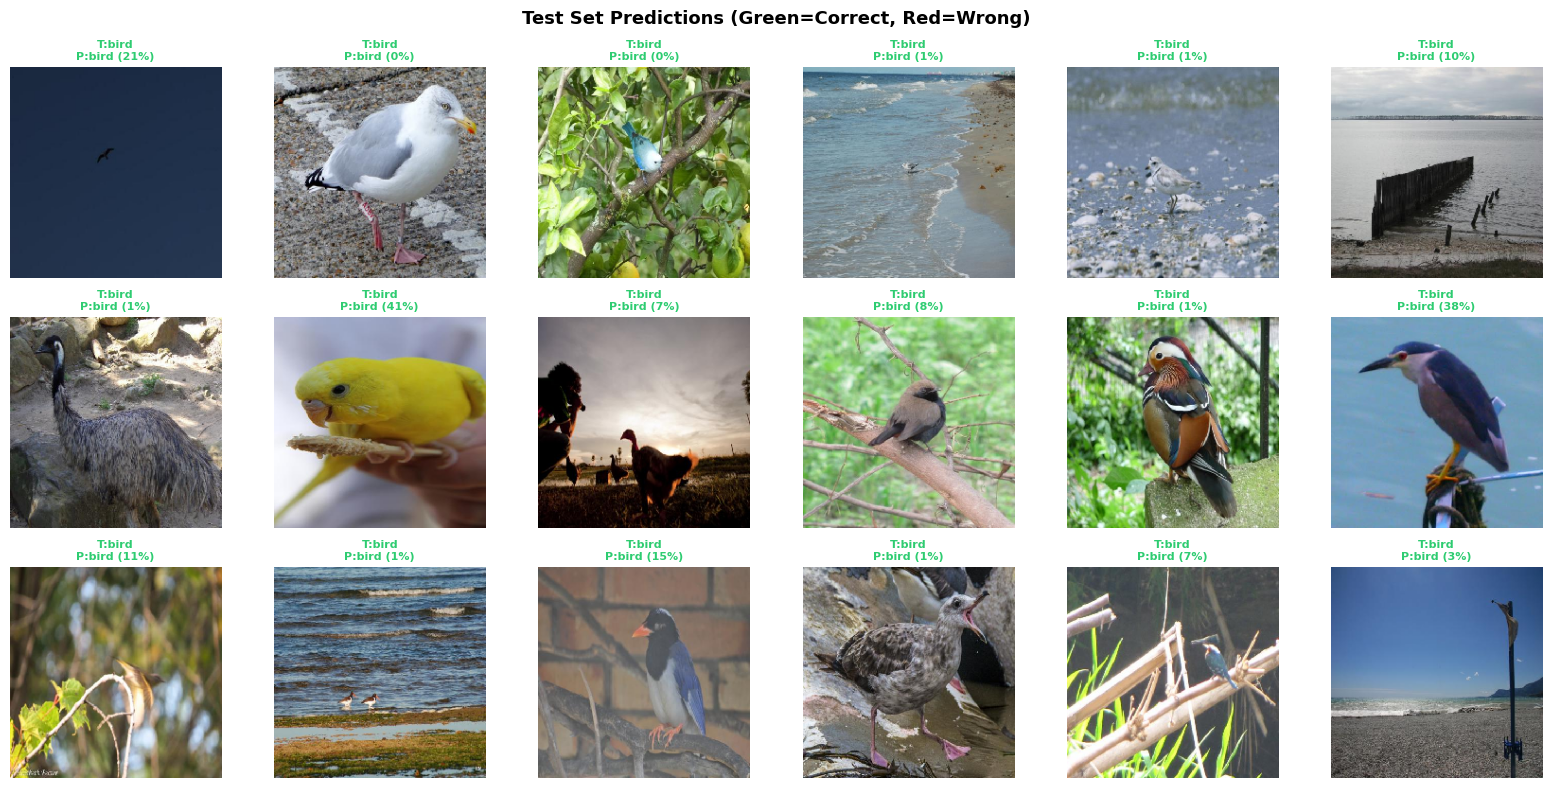

Phase 5 complete!


In [11]:
# Load best model and show sample predictions
best_model = tf.keras.models.load_model('best_model.keras')
test_gen.reset()

images, labels = next(test_gen)
probs  = best_model.predict(images, verbose=0).flatten()
preds  = (probs > 0.5).astype(int)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i >= len(images): ax.axis('off'); continue
    ax.imshow(images[i])
    true_label = CLASS_NAMES[int(labels[i])]
    pred_label = CLASS_NAMES[preds[i]]
    correct    = true_label == pred_label
    color      = '#2ECC71' if correct else '#E74C3C'
    ax.set_title(f'T:{true_label}\nP:{pred_label} ({probs[i]*100:.0f}%)',
                 fontsize=8, color=color, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.suptitle('Test Set Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase 5 complete!')